# Installiere ultralytics Bibliothek

In [1]:
!pip install ultralytics

   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 1.1/1.1 MB ? eta 0:00:00
   ---------------------------------------- 0.0/783.6 kB ? eta -:--:--
   --------------------------------------- 783.6/783.6 kB 34.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/41.3 MB ? eta -:--:--
   ---------------------- ----------------- 23.3/41.3 MB 113.6 MB/s eta 0:00:01
   ---------------------------------------  41.2/41.3 MB 109.1 MB/s eta 0:00:01
   ---------------------------------------  41.2/41.3 MB 109.1 MB/s eta 0:00:01
   ---------------------------------------- 41.3/41.3 MB 64.1 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import Libraries

In [3]:
import os
from zipfile import ZipFile
from ultralytics import YOLO

In [21]:
path = "D:/Studium/5. Semester/PA2/Glass-Defect-Detection-Evaluating-Object-Detection-Models/Coding/Datasets/Dataset_kaggle_glass/Kaggle_Dataset.v1i.yolov11"
print(path)

D:/Studium/5. Semester/PA2/Glass-Defect-Detection-Evaluating-Object-Detection-Models/Coding/Datasets/Dataset_kaggle_glass/Kaggle_Dataset.v1i.yolov11


## Load in the data and unzip it

In [ ]:
# Create the directory if it doesn't exist
extract_dir = "data"
os.makedirs(extract_dir, exist_ok=True)

with ZipFile("kaggle_glass_defect_YOLO.zip", "r") as data_set:
    data_set.extractall(extract_dir)

## Load the Model


In [5]:
model = YOLO("yolo11n.pt")

## Create configurations


In [22]:
DATA_YAML = path +"/data.yaml"
MODEL_PATH = "yolo11n.pt"
data_set_dir = "data"

## Fine-Tuning with Hyperparameters

In [19]:
results = model.train(
    data = DATA_YAML,
    epochs = 100,
    batch = 16,
    lrf = 0.01,
    val = True
)

Ultralytics 8.3.225  Python-3.12.10 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1070, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:/Studium/5. Semester/PA2/Glass-Defect-Detection-Evaluating-Object-Detection-Models/Coding/Datasets/Dataset_kaggle_glass/Kaggle_Dataset.v1i.yolov11/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=D:/Studium/5. Semester/PA2/Glass-Defect-Detection-Evaluati

RuntimeError: Caught RuntimeError in pin memory thread for device 0.
Original Traceback (most recent call last):
  File "d:\Studium\5. Semester\venv\Lib\site-packages\torch\utils\data\_utils\pin_memory.py", line 43, in do_one_step
    data = pin_memory(data, device)
           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Studium\5. Semester\venv\Lib\site-packages\torch\utils\data\_utils\pin_memory.py", line 77, in pin_memory
    {k: pin_memory(sample, device) for k, sample in data.items()}
        ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Studium\5. Semester\venv\Lib\site-packages\torch\utils\data\_utils\pin_memory.py", line 66, in pin_memory
    return data.pin_memory(device)
           ^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: CUDA error: resource already mapped
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


#### Testing weigths on the test dataset

In [24]:
model = YOLO(path + "/best.pt")

In [25]:
metrics = model.val(
    data = DATA_YAML,
    split  = "test",
    batch = 16
    )

print(metrics.box.map)

Ultralytics 8.3.225  Python-3.12.10 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1070, 8192MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 686.739.3 MB/s, size: 120.5 KB)
val: Scanning D:\Studium\5. Semester\PA2\Glass-Defect-Detection-Evaluating-Object-Detection-Models\Coding\Datasets\Dataset_kaggle_glass\Kaggle_Dataset.v1i.yolov11\test\labels.cache... 21 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 21/21  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 0.5it/s 3.8s12.0s
                   all         21         27      0.972          1      0.995      0.756
Speed: 2.5ms preprocess, 8.4ms inference, 0.0ms loss, 3.8ms postprocess per image
Results saved to D:\Studium\5. Semester\PA2\Glass-Defect-Detection-Evaluating-Object-Detection-Models\Coding\Model_Code\YOLO\runs\detect\val
0.7561889127984085


In [30]:
import time
import cv2
import torch # Nur zur Überprüfung, ob eine GPU verfügbar ist

# Laden des besten Modells
model = YOLO('best.pt')

# Wichtig: Gerät auf CPU setzen! (Auch wenn eine GPU vorhanden ist)
device = 'cpu'
if torch.cuda.is_available():
    print("GPU erkannt, aber Inferenz wird auf CPU forciert.")

# Testbild laden (oder eine Schleife über den gesamten Test-Datensatz)
image = cv2.imread(path + '/test/images/image_10_jpg.rf.86f3dc2cbb9d15047ab07ff149cf3a2f.jpg')

# Inferenz-Schleife für genaue Messung
num_runs = 100
start_time = time.time()

for _ in range(num_runs):
    # Inferenz mit YOLOv11 Nano auf der CPU
    results = model(
        image,
        device=device,
        verbose=False # Ausgabe unterdrücken
    )
    # Beachten Sie, dass das Post-Processing (NMS) in der Zeit enthalten ist.

end_time = time.time()
avg_time_ms = ((end_time - start_time) / num_runs) * 1000
fps = 1000 / avg_time_ms

print(f"\nDurchschnittliche Inferenzzeit auf {device}: {avg_time_ms:.2f} ms")
print(f"Geschwindigkeit: {fps:.2f} FPS")

GPU erkannt, aber Inferenz wird auf CPU forciert.

Durchschnittliche Inferenzzeit auf cpu: 65.29 ms
Geschwindigkeit: 15.32 FPS


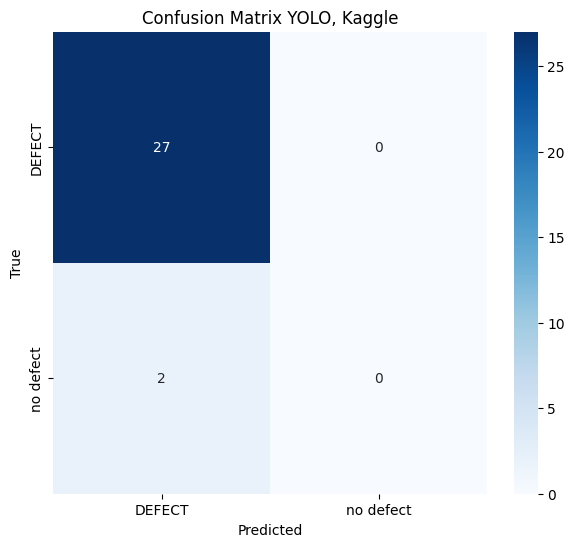


Konsolidierte 2x2 Matrix (True=Reihe vs. Predicted=Spalte):

           DEFECT  no defect
DEFECT         27          0
no defect       2          0


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Daten aus dem Bild extrahieren und vorbereiten ---

# Originaldaten aus dem Bild (Y-Achse=Predicted, X-Achse=True):
# True (Spalten) -> DEFECT, background
# Predicted (Reihen) -> DEFECT, background
# -----------------------------------
# DEFECT (True) | 27 (TP), 2 (FP)
# background (True) | ? (FN), ? (TN)
# -----------------------------------

# Da im Bild nur die erste Zeile der Predicted-Achse sichtbar ist (27 und 2), 
# und die zweite Zeile der Predicted-Achse (background) leer ist, nehmen wir an, 
# dass die leeren Zellen '0' sind.
# ACHTUNG: Die Achsen im Bild sind vertauscht. Wir transponieren die Matrix, 
# um sie in die Standardform (True=Reihe, Predicted=Spalte) zu bringen.

# Die Daten, wie sie im Bild als (Predicted-Reihe, True-Spalte) gelesen werden:
# row_p_defect = [27, 2] # Predicted DEFECT
# row_p_bg = [0, 0]     # Predicted background (angenommen)

# Matrix mit der Anordnung aus dem BILD (Predicted x True)
cm_raw_data = np.array([
    [27, 2],
    [0, 0] 
])

# Standard-Labels (True=Reihe, Predicted=Spalte)
standard_labels = ['DEFECT', 'no defect']

# Transponieren der Matrix: (Predicted x True) --> (True x Predicted)
# Dies korrigiert die vertauschte Achsenanordnung des Bildes.
cm_final_data = cm_raw_data.T

# --- 2. Plot der korrigierten 2x2 Matrix ---
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_final_data, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,
    xticklabels=standard_labels,
    yticklabels=standard_labels
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix YOLO, Kaggle')
plt.show()

# Print der finalen Matrix
print("\nKonsolidierte 2x2 Matrix (True=Reihe vs. Predicted=Spalte):\n")
df = pd.DataFrame(cm_final_data, index=standard_labels, columns=standard_labels)
print(df)